# Evaluation Analysis

Loads pre-computed results from `eval_synthcity.py`, `eval_sdmetrics.py`, and `eval_tapas.py`.
Does **not** re-run any evaluation — presentation-ready artifact only.

**Methods:** Bayesian Network (no DP), PrivBayes (DP), CTGAN (no DP), DPGAN (DP)
**Dataset:** Adult Census

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

RESULTS = Path('../results')


# Repo palette (from the reference chart): orange + grey primary, teal + pink accent.
ORANGE, GREY, TEAL, PINK = "#CE4E36", "#3A3A3A", "#8CA9A0", "#D2B4B1"

METHOD_ORDER  = ['bayesian_network', 'privbayes', 'ctgan', 'dpgan']
METHOD_LABELS = {
    'bayesian_network': 'BN',
    'privbayes':        'PrivBayes',
    'ctgan':            'CTGAN',
    'dpgan':            'DPGAN',
}
COLORS = {
    'bayesian_network': ORANGE,
    'privbayes':        GREY,
    'ctgan':            TEAL,
    'dpgan':            PINK,
}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

## Load results

In [38]:
sc  = pd.read_csv(RESULTS / 'synthcity_results.csv', index_col=0)
sdm = pd.read_csv(RESULTS / 'sdmetrics_results.csv')
tap = pd.read_csv(RESULTS / 'tapas_results.csv')

print('Synthcity:', sc.shape)
print('SDMetrics:', sdm.shape)
print('TAPAS:    ', tap.shape)

Synthcity: (32, 11)
SDMetrics: (4, 5)
TAPAS:     (4, 13)


In [39]:
effeps_privbayes = pd.read_csv("../results/tapas_results/eff_eps_results/privbayes/effeps_privbayes.csv")
effeps_privbayes[["attack", "tp", "fp", "auc", "mia_advantage", "privacy_gain"]]
effeps_privbayes[["attack", "eps_low_90","eps_high_90","eps_low_95","eps_high_95","eps_low_99","eps_high_99"]]

,attack,eps_low_90,eps_high_90,eps_low_95,eps_high_95,eps_low_99,eps_high_99
0,Groundhog,2.390153,inf,2.209964,inf,1.878477,inf
1,ShadowModelling(RandomQueries),2.390153,inf,2.209964,inf,1.878477,inf
2,"LocalNeighbourhood(L_2, 0.250411558405805, acc...",0.000000,0.085788,0.000000,0.101908,0.000000,0.139336
3,ProbabilityEstimation(KernelDensity()),0.000000,0.085788,0.000000,0.101908,0.000000,0.139336


In [40]:
# Pivot Synthcity results: rows = method, columns = metric
# Synthcity benchmark is in long format: rows are (method, metric_name, direction, ...)
print(sc.columns.tolist())
sc.head(10)

['method', 'min', 'max', 'mean', 'stddev', 'median', 'iqr', 'rounds', 'errors', 'durations', 'direction']


,method,min,max,mean,stddev,median,iqr,rounds,errors,durations,direction
performance.linear_model.gt,bayesian_network,8.094591e-01,8.094591e-01,8.094591e-01,0.0,8.094591e-01,0.0,1,0,0.02,maximize
performance.linear_model.syn_id,bayesian_network,6.653153e-01,6.653153e-01,6.653153e-01,0.0,6.653153e-01,0.0,1,0,0.02,maximize
performance.linear_model.syn_ood,bayesian_network,6.627646e-01,6.627646e-01,6.627646e-01,0.0,6.627646e-01,0.0,1,0,0.02,maximize
performance.xgb.gt,bayesian_network,9.198841e-01,9.198841e-01,9.198841e-01,0.0,9.198841e-01,0.0,1,0,0.02,maximize
performance.xgb.syn_id,bayesian_network,7.672858e-01,7.672858e-01,7.672858e-01,0.0,7.672858e-01,0.0,1,0,0.02,maximize
performance.xgb.syn_ood,bayesian_network,7.758381e-01,7.758381e-01,7.758381e-01,0.0,7.758381e-01,0.0,1,0,0.02,maximize
performance.feat_rank_distance.corr,bayesian_network,2.251508e-01,2.251508e-01,2.251508e-01,0.0,2.251508e-01,0.0,1,0,0.21,minimize
performance.feat_rank_distance.pvalue,bayesian_network,1.042902e-108,1.042902e-108,1.042902e-108,0.0,1.042902e-108,0.0,1,0,0.21,minimize
performance.linear_model.gt,privbayes,8.094591e-01,8.094591e-01,8.094591e-01,0.0,8.094591e-01,0.0,1,0,0.02,maximize
performance.linear_model.syn_id,privbayes,7.805903e-01,7.805903e-01,7.805903e-01,0.0,7.805903e-01,0.0,1,0,0.02,maximize


In [41]:
# Pivot to wide format: method x metric
# Actual CSV: row index = metric name, columns include 'method' and 'mean'
sc_reset = sc.reset_index().rename(columns={'index': 'metric'})
sc_wide = sc_reset.pivot_table(index='method', columns='metric', values='mean')
sc_wide = sc_wide.reindex(METHOD_ORDER)
sc_wide.index = [METHOD_LABELS[m] for m in sc_wide.index]
sc_wide

metric,performance.feat_rank_distance.corr,performance.feat_rank_distance.pvalue,performance.linear_model.gt,performance.linear_model.syn_id,performance.linear_model.syn_ood,performance.xgb.gt,performance.xgb.syn_id,performance.xgb.syn_ood
BN,0.225151,1.042902e-108,0.809459,0.665315,0.662765,0.919884,0.767286,0.775838
PrivBayes,0.613909,0.000000e+00,0.809459,0.780590,0.784267,0.919884,0.882615,0.887115
CTGAN,0.443831,0.000000e+00,0.809459,0.746046,0.748458,0.919884,0.871867,0.871520
DPGAN,-0.028361,5.269805e-03,0.809459,0.756558,0.759812,0.919884,0.393917,0.394588


In [42]:
# SDMetrics — already wide
sdm = sdm.set_index('method').reindex(METHOD_ORDER)
sdm.index = [METHOD_LABELS[m] for m in sdm.index]
sdm

,KSComplement,TVComplement,CorrelationSimilarity,ContingencySimilarity
BN,0.728923,0.896982,0.972600,0.788836
PrivBayes,0.935975,0.946580,0.968712,0.877143
CTGAN,0.705561,0.852280,0.985434,0.727693
DPGAN,0.199099,0.209816,0.955723,0.058544


In [43]:
# TAPAS — already wide
tap = tap.set_index('method').reindex(METHOD_ORDER)
tap.index = [METHOD_LABELS[m] for m in tap.index]
tap

,mia_auc,mia_advantage,mia_privacy_gain,mia_eff_epsilon,mia_tp,mia_fp,aia_auc,aia_advantage,aia_privacy_gain,aia_eff_epsilon,eps_low_90,eps_high_90
BN,0.514911,0.046667,0.953333,1.203973,0.523333,0.476667,0.755543,0.207067,0.792933,3.799172,0.0,0.030240
PrivBayes,0.498189,-0.006667,1.006667,0.302281,0.496667,0.503333,0.834531,0.306658,0.693342,inf,0.0,0.018037
CTGAN,0.461489,-0.073333,1.073333,0.980829,0.463333,0.536667,0.874886,0.444876,0.555124,inf,0.0,0.013562
DPGAN,0.506633,0.040000,0.960000,0.788457,0.520000,0.480000,0.730269,0.024264,0.975736,inf,0.0,0.037938


## Master comparison table

In [44]:
# Pull key metrics from each source
key_utility  = ['BinaryLogisticRegression_F1', 'LogisticDetection']
key_fidelity = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
key_privacy  = ['DCRBaselineProtection', 'NewRowSynthesis',
                'mia_auc', 'mia_advantage', 'mia_eff_epsilon',
                'aia_auc', 'aia_eff_epsilon', 'eps_low_90', 'eps_high_90']

master = pd.concat([
    sdm[key_fidelity],
    sdm[[c for c in key_utility if c in sdm.columns]],
    tap[[c for c in key_privacy if c in tap.columns]],
], axis=1)

master.round(4)

,KSComplement,TVComplement,CorrelationSimilarity,ContingencySimilarity,mia_auc,mia_advantage,mia_eff_epsilon,aia_auc,aia_eff_epsilon,eps_low_90,eps_high_90
BN,0.7289,0.8970,0.9726,0.7888,0.5149,0.0467,1.2040,0.7555,3.7992,0.0,0.0302
PrivBayes,0.9360,0.9466,0.9687,0.8771,0.4982,-0.0067,0.3023,0.8345,inf,0.0,0.0180
CTGAN,0.7056,0.8523,0.9854,0.7277,0.4615,-0.0733,0.9808,0.8749,inf,0.0,0.0136
DPGAN,0.1991,0.2098,0.9557,0.0585,0.5066,0.0400,0.7885,0.7303,inf,0.0,0.0379


## Plot 1 — Fidelity comparison

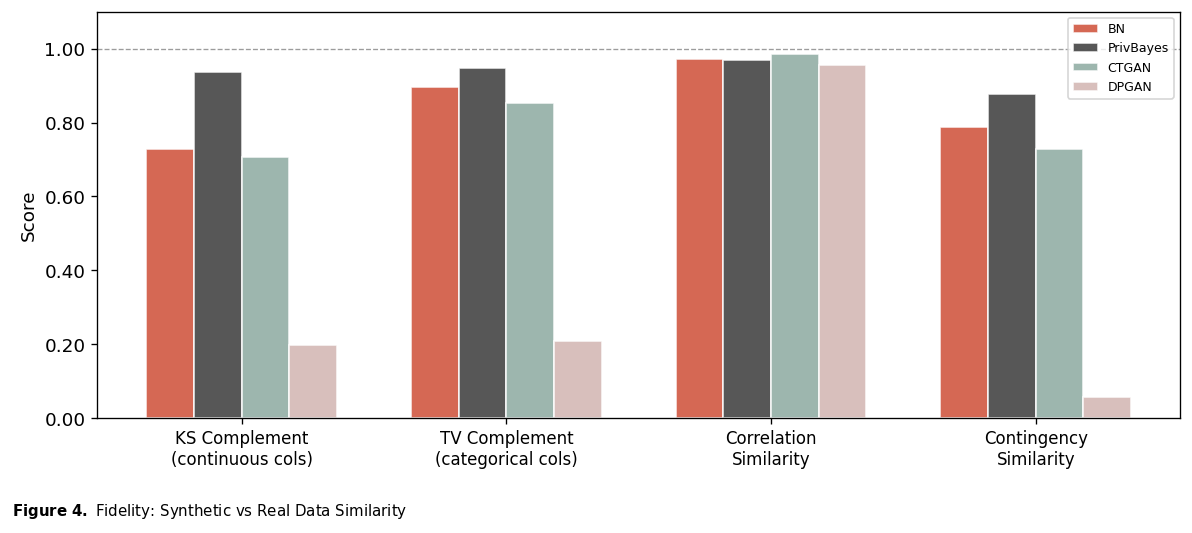

In [48]:
fidelity_metrics = ['KSComplement', 'TVComplement', 'CorrelationSimilarity', 'ContingencySimilarity']
fidelity_labels  = ['KS Complement\n(continuous cols)', 'TV Complement\n(categorical cols)',
                     'Correlation\nSimilarity', 'Contingency\nSimilarity']

available = [m for m in fidelity_metrics if m in master.columns]
n = len(available)
x = np.arange(n)
width = 0.18

fig, ax = plt.subplots(figsize=(10, 4.5))
for i, (method, label) in enumerate(zip(METHOD_ORDER, METHOD_LABELS.values())):
    label_str = METHOD_LABELS[method]
    if label_str in master.index:
        vals = [master.loc[label_str, m] if m in master.columns else np.nan for m in available]
        ax.bar(x + i * width - 1.5 * width, vals, width, label=label_str,
               color=COLORS[method], alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels([fidelity_labels[fidelity_metrics.index(m)] for m in available], fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.axhline(1.0, color=GREY, linestyle='--', linewidth=0.8, alpha=0.5)
ax.legend(loc='upper right', fontsize=7.5)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
# Leave space at the bottom for caption
plt.tight_layout(rect=[0, 0.08, 1, 1])

# Add left-aligned caption
fig.text(
    0.01,
    0.02,
    r"$\bf{Figure\ 4.}$ Fidelity: Synthetic vs Real Data Similarity",
    ha="left",
    va="bottom",
    fontsize=9
)

plt.savefig(RESULTS / 'fidelity_comparison.png', bbox_inches='tight')
plt.show()

## Plot 2 — Utility vs Privacy tradeoff

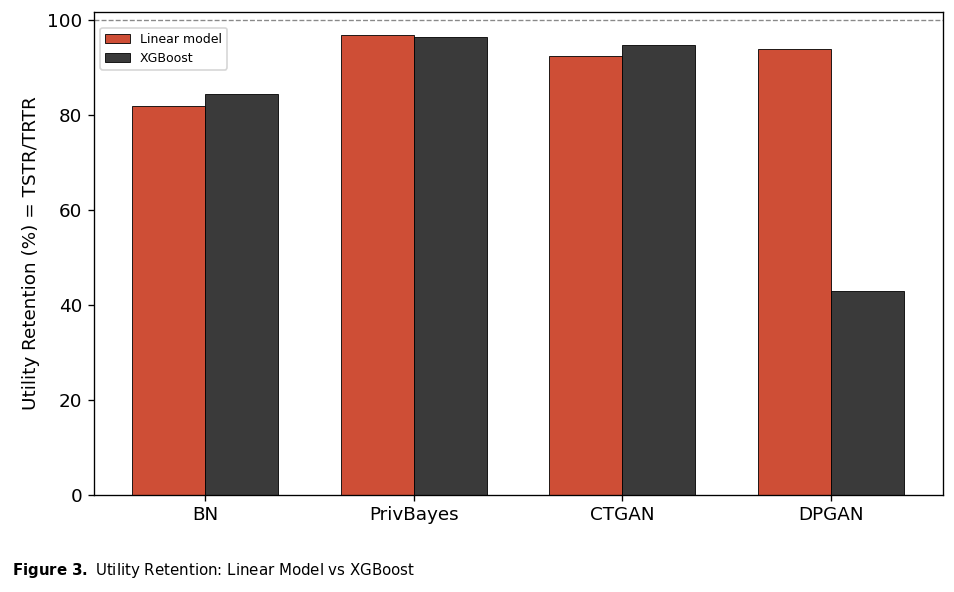

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(METHOD_ORDER))
width = 0.35

linear_retained = []
xgb_retained = []
for method in METHOD_ORDER:
    label = METHOD_LABELS[method]
    lm_gt = sc_wide.loc[label, 'performance.linear_model.gt']
    lm_ood = sc_wide.loc[label, 'performance.linear_model.syn_ood']
    xgb_gt = sc_wide.loc[label, 'performance.xgb.gt']
    xgb_ood = sc_wide.loc[label, 'performance.xgb.syn_ood']
    linear_retained.append(100 * lm_ood / lm_gt)
    xgb_retained.append(100 * xgb_ood / xgb_gt)

ax.bar(x - width/2, linear_retained, width, label='Linear model', color=ORANGE, edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, xgb_retained, width, label='XGBoost', color=GREY, edgecolor='black', linewidth=0.5)

ax.axhline(100, color=GREY, linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_ylabel('Utility Retention (%) = TSTR/TRTR', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABELS[m] for m in METHOD_ORDER])
ax.legend(
    loc='upper left',
    bbox_to_anchor=(0, 0.98),
    fontsize=7.5
)
# Leave space at the bottom for caption
plt.tight_layout(rect=[0, 0.08, 1, 1])

# Add left-aligned caption
fig.text(
    0.01,
    0.02,
    r"$\bf{Figure\ 3.}$ Utility Retention: Linear Model vs XGBoost",
    ha="left",
    va="bottom",
    fontsize=9
)
plt.savefig(RESULTS / 'utility_metric_comparison.png', bbox_inches='tight')
plt.show()

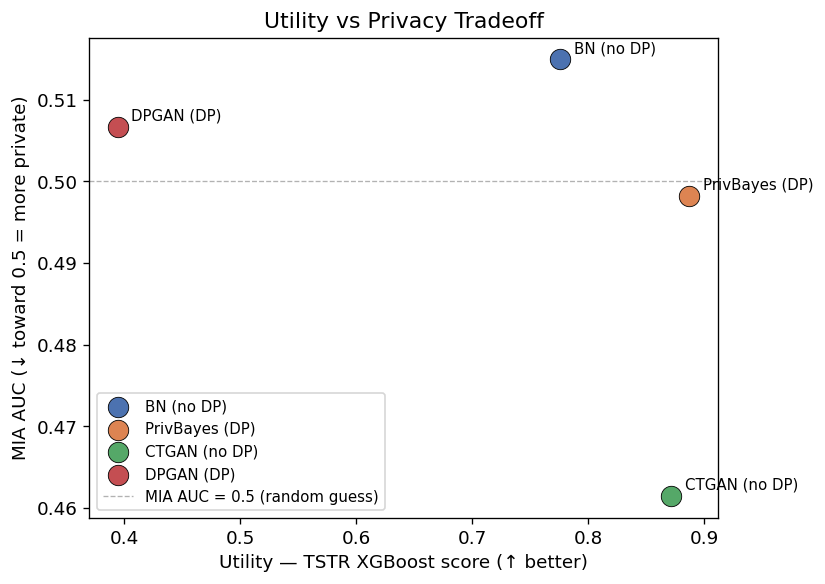

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))

for method in METHOD_ORDER:
    label = METHOD_LABELS[method]
    utility = sc_wide.loc[label, 'performance.xgb.syn_ood']
    privacy = master.loc[label, 'mia_auc']

    ax.scatter(utility, privacy, s=150, color=COLORS[method],
               label=label, zorder=5, edgecolors='black', linewidth=0.5)
    ax.annotate(label, (utility, privacy),
                textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Utility — TSTR XGBoost score (↑ better)', fontsize=11)
ax.set_ylabel('MIA AUC (↓ toward 0.5 = more private)', fontsize=11)
ax.set_title('Utility vs Privacy Tradeoff')
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6,
           label='MIA AUC = 0.5 (random guess)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'utility_privacy_tradeoff.png', bbox_inches='tight')
plt.show()

## Plot 3 — Effective epsilon (ε_eff) comparison

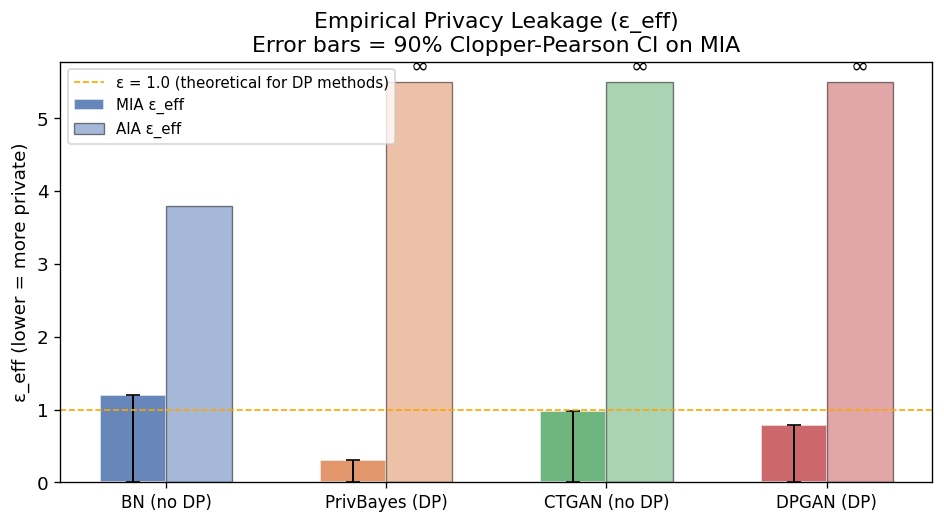

In [14]:
# aia_eff_epsilon is inf when AIA FP rate = 0 (ln(TP/0) = inf)
# Cap at INF_CAP for display and annotate with ∞ symbol
INF_CAP = 5.5

fig, ax = plt.subplots(figsize=(8, 4.5))

labels_plot = [METHOD_LABELS[m] for m in METHOD_ORDER if METHOD_LABELS[m] in master.index]
x = np.arange(len(labels_plot))
colors_plot = [COLORS[m] for m in METHOD_ORDER if METHOD_LABELS[m] in master.index]

mia_eps     = [master.loc[l, 'mia_eff_epsilon'] if 'mia_eff_epsilon' in master.columns else np.nan
               for l in labels_plot]
aia_eps_raw = [master.loc[l, 'aia_eff_epsilon'] if 'aia_eff_epsilon' in master.columns else np.nan
               for l in labels_plot]
eps_low     = [master.loc[l, 'eps_low_90']  if 'eps_low_90'  in master.columns else np.nan for l in labels_plot]
eps_high    = [master.loc[l, 'eps_high_90'] if 'eps_high_90' in master.columns else np.nan for l in labels_plot]

aia_eps = [min(v, INF_CAP) if np.isfinite(v) else INF_CAP for v in aia_eps_raw]

width = 0.3
ax.bar(x - width/2, mia_eps, width, label='MIA ε_eff', color=colors_plot, alpha=0.85, edgecolor='white')
ax.bar(x + width/2, aia_eps, width, label='AIA ε_eff', color=colors_plot, alpha=0.5,
       edgecolor='black', linewidth=0.8)

# Annotate bars capped from inf
for xi, (raw, capped) in enumerate(zip(aia_eps_raw, aia_eps)):
    if not np.isfinite(raw):
        ax.text(xi + width/2, capped + 0.08, '∞', ha='center', va='bottom', fontsize=13)

# CP bounds on MIA as error bars
eps_err_low  = np.array([max(0, m - l) for m, l in zip(mia_eps, eps_low)])
eps_err_high = np.array([max(0, h - m) for m, h in zip(mia_eps, eps_high)])
ax.errorbar(x - width/2, mia_eps,
            yerr=[eps_err_low, eps_err_high],
            fmt='none', color='black', capsize=4, linewidth=1.2)

ax.axhline(1.0, color='orange', linestyle='--', linewidth=1,
           label='ε = 1.0 (theoretical for DP methods)')
ax.set_xticks(x)
ax.set_xticklabels(labels_plot, fontsize=10)
ax.set_ylabel('ε_eff (lower = more private)')
ax.set_title('Empirical Privacy Leakage (ε_eff)\nError bars = 90% Clopper-Pearson CI on MIA')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'epsilon_comparison.png', bbox_inches='tight')
plt.show()

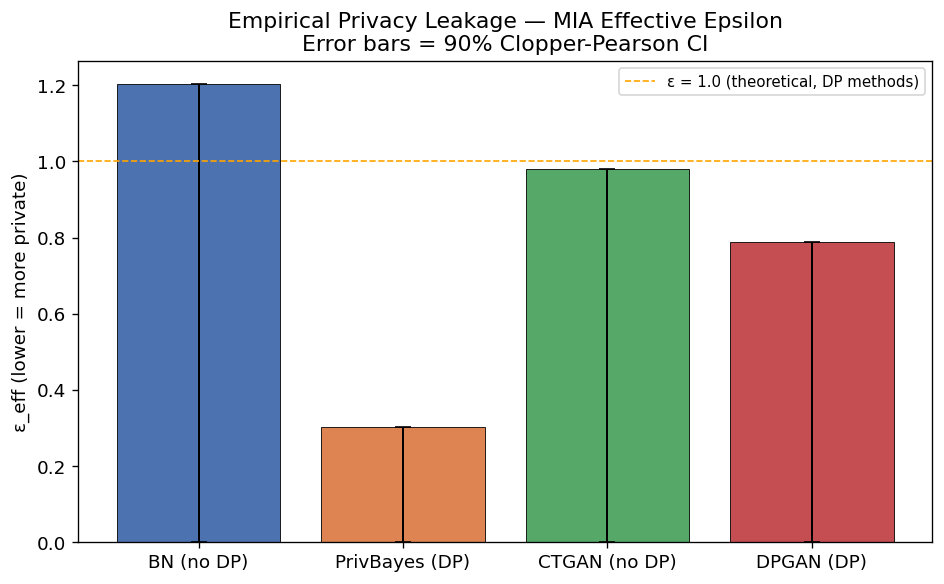

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

mia_eps = [master.loc[METHOD_LABELS[m], 'mia_eff_epsilon'] for m in METHOD_ORDER]
eps_low = [master.loc[METHOD_LABELS[m], 'eps_low_90'] for m in METHOD_ORDER]
eps_high = [master.loc[METHOD_LABELS[m], 'eps_high_90'] for m in METHOD_ORDER]

# error bars need [value - low, high - value], clipped at 0
err_lower = [max(0, v - lo) for v, lo in zip(mia_eps, eps_low)]
err_upper = [max(0, hi - v) for v, hi in zip(mia_eps, eps_high)]

ax.bar(np.arange(len(METHOD_ORDER)), mia_eps,
       color=[COLORS[m] for m in METHOD_ORDER], edgecolor='black', linewidth=0.5,
       yerr=[err_lower, err_upper], capsize=5, error_kw={'elinewidth': 1.2})

ax.axhline(1.0, color='orange', linestyle='--', linewidth=1, label='ε = 1.0 (theoretical, DP methods)')
ax.set_ylabel('ε_eff (lower = more private)', fontsize=11)
ax.set_xticks(np.arange(len(METHOD_ORDER)))
ax.set_xticklabels([METHOD_LABELS[m] for m in METHOD_ORDER])
ax.set_title('Empirical Privacy Leakage — MIA Effective Epsilon\nError bars = 90% Clopper-Pearson CI')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'mia_effective_epsilon.png', bbox_inches='tight')
plt.show()

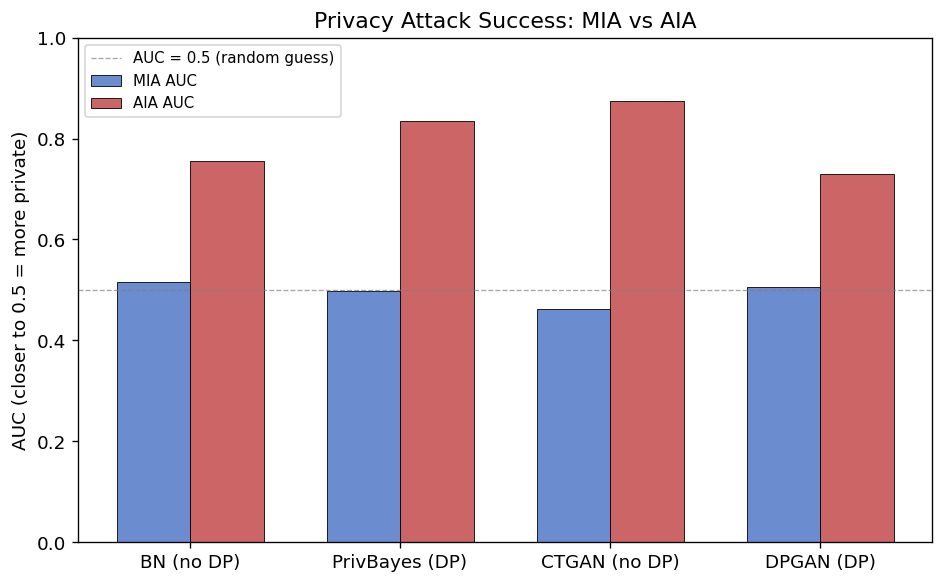

In [10]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(METHOD_ORDER))
width = 0.35

mia_auc = [master.loc[METHOD_LABELS[m], 'mia_auc'] for m in METHOD_ORDER]
aia_auc = [master.loc[METHOD_LABELS[m], 'aia_auc'] for m in METHOD_ORDER]

ax.bar(x - width/2, mia_auc, width, label='MIA AUC', color='#6b8cce', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, aia_auc, width, label='AIA AUC', color='#cc6666', edgecolor='black', linewidth=0.5)

ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.7, label='AUC = 0.5 (random guess)')
ax.set_ylabel('AUC (closer to 0.5 = more private)', fontsize=11)
ax.set_ylim(0, 1)
ax.set_xticks(x)
ax.set_xticklabels([METHOD_LABELS[m] for m in METHOD_ORDER])
ax.set_title('Privacy Attack Success: MIA vs AIA')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(RESULTS / 'privacy_attack_success.png', bbox_inches='tight')
plt.show()

## Overhead summary

In [12]:
overhead_path = Path('../evaluation/eval_overhead.csv')
if overhead_path.exists():
    display(pd.read_csv(overhead_path))
else:
    print('eval_overhead.csv not found — run evaluation scripts first')

,script,runtime_sec,peak_memory_mb,methods_succeeded,methods_failed
0,eval_tapas,28.53,137.79,4,0
1,eval_sdmetrics,13.19,143.63,4,0
